In [1]:
from google.colab import files
import zipfile, sys

uploaded = files.upload()

with zipfile.ZipFile("MEFAMEpy_corregido.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

sys.path.append("/content")

from MEFAMEpy import *

Saving MEFAMEpy_corregido.zip to MEFAMEpy_corregido.zip


In [5]:
from MEFAMEpy import *
import pandas as pd

# ============================================================
# 1. Unidades
# ============================================================
# Se trabajará en Tonf y metros.

# E = 21000 kgf/mm2
# Conversión: 1 kgf/mm2 = 1000 Tonf/m2
E = 21000 * 1000  # Tonf/m2

# Áreas
A_13579 = 32e-4   # 32 cm2 = 32 * 10^-4 m2
A_2468  = 27e-4   # 27 cm2 = 27 * 10^-4 m2

# ============================================================
# 2. Crear modelo
# ============================================================
modelo = Modelo(2, 2)

# ============================================================
# 3. Crear nodos
# ============================================================
n1 = Nodo(1, 2, [0.0, 0.0])
n2 = Nodo(2, 2, [3.0, 0.0])
n3 = Nodo(3, 2, [3.0, 4.5])
n4 = Nodo(4, 2, [6.0, 4.5])
n5 = Nodo(5, 2, [6.0, 0.0])
n6 = Nodo(6, 2, [9.0, 0.0])

nodos = [n1, n2, n3, n4, n5, n6]
modelo.agregarNodos(nodos)

# ============================================================
# 4. Crear elementos
# ============================================================
# Elementos 1, 3, 5, 7, 9 tienen A = 32 cm2
# Elementos 2, 4, 6, 8 tienen A = 27 cm2

e1 = Biela2D(1, n1, n3, A_13579, E)
e2 = Biela2D(2, n1, n2, A_2468,  E)
e3 = Biela2D(3, n2, n3, A_13579, E)
e4 = Biela2D(4, n2, n5, A_2468,  E)
e5 = Biela2D(5, n3, n5, A_13579, E)
e6 = Biela2D(6, n3, n4, A_2468,  E)
e7 = Biela2D(7, n4, n5, A_13579, E)
e8 = Biela2D(8, n5, n6, A_2468,  E)
e9 = Biela2D(9, n4, n6, A_13579, E)

elementos = [e1, e2, e3, e4, e5, e6, e7, e8, e9]
modelo.agregarElementos(elementos)

# ============================================================
# 5. Restricciones de apoyo
# ============================================================
# GDL 1 = desplazamiento en x
# GDL 2 = desplazamiento en y

modelo.agregarRestricciones([
    RestriccionNodo("R1", n1, [1, 2]),  # Nodo 1 articulado: ux = 0, uy = 0
    RestriccionNodo("R4", n4, [2]),     # Nodo 4 rodillo superior: uy = 0
    RestriccionNodo("R6", n6, [2])      # Nodo 6 rodillo inferior: uy = 0
])



In [6]:
# ============================================================
# 6. Cargas externas
# ============================================================
modelo.agregarPatronesDeCargas([
    PatronDeCargasConstante("P1", [
        CargaNodo("C3x", n3, [4.0, 0.0]),     # 4 Tonf hacia la derecha
        CargaNodo("C2y", n2, [0.0, -25.0]),   # 25 Tonf hacia abajo
        CargaNodo("C5y", n5, [0.0, -20.0])    # 20 Tonf hacia abajo
    ])
])

In [7]:
# ============================================================
# 7. Análisis estático
# ============================================================
analisis = AnalisisEstatico(modelo)
analisis.analizar()

array([ 0.00062951, -0.00465696,  0.00240851, -0.00298285,  0.00224296,
        0.00125902, -0.00222009,  0.00142457])

In [8]:
# ============================================================
# 8. Resultados: desplazamientos nodales
# ============================================================
tabla_desplazamientos = pd.DataFrame([
    [
        nodo.obtenerEtiqueta(),
        nodo.obtenerDesplazamientos()[0],
        nodo.obtenerDesplazamientos()[1],
        nodo.obtenerDesplazamientos()[0] * 1000,
        nodo.obtenerDesplazamientos()[1] * 1000
    ]
    for nodo in nodos
], columns=["Nodo", "ux [m]", "uy [m]", "ux [mm]", "uy [mm]"])

tabla_desplazamientos

,Nodo,ux [m],uy [m],ux [mm],uy [mm]
0,1,0.000000,0.000000,0.000000,0.000000
1,2,0.000630,-0.004657,0.629511,-4.656957
2,3,0.002409,-0.002983,2.408510,-2.982850
3,4,0.002243,0.000000,2.242962,0.000000
4,5,0.001259,-0.002220,1.259022,-2.220091
5,6,0.001425,0.000000,1.424570,0.000000


In [9]:
# ============================================================
# 9. Resultados: reacciones
# ============================================================
tabla_reacciones = pd.DataFrame([
    [
        nodo.obtenerEtiqueta(),
        nodo.obtenerReacciones()[0],
        nodo.obtenerReacciones()[1]
    ]
    for nodo in nodos
], columns=["Nodo", "Rx [Tonf]", "Ry [Tonf]"])

tabla_reacciones

,Nodo,Rx [Tonf],Ry [Tonf]
0,1,-4.000000e+00,1.184664e+01
1,2,0.000000e+00,0.000000e+00
2,3,7.105427e-15,1.776357e-15
3,4,-7.105427e-15,2.846009e+01
4,5,5.329071e-15,-7.105427e-15
5,6,-3.552714e-15,4.693275e+00


In [10]:
# ============================================================
# 10. Resultados: fuerza axial por elemento
# ============================================================
tabla_axiales = pd.DataFrame([
    [
        elemento.obtenerEtiqueta(),
        elemento.obtenerFuerzaAxial()
    ]
    for elemento in elementos
], columns=["Elemento", "N [Tonf]"])

tabla_axiales

,Elemento,N [Tonf]
0,1,-14.237886
1,2,11.897758
2,3,25.000000
3,4,11.897758
4,5,-15.808374
5,6,-3.128850
6,7,33.153363
7,8,3.128850
8,9,-5.640614


Factor de escala para deformada = 287.28


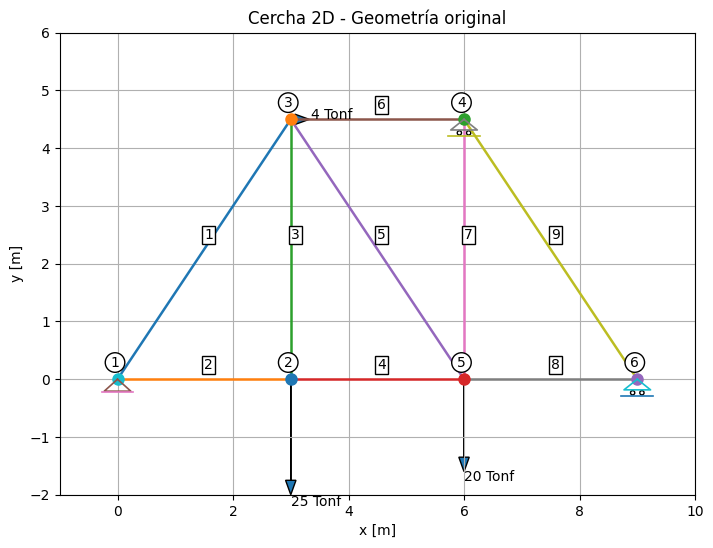

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm, colors

# ============================================================
# 1. Datos geométricos del modelo
# ============================================================
# Coordenadas originales de los nodos
coords = {
    1: np.array([0.0, 0.0]),
    2: np.array([3.0, 0.0]),
    3: np.array([3.0, 4.5]),
    4: np.array([6.0, 4.5]),
    5: np.array([6.0, 0.0]),
    6: np.array([9.0, 0.0]),
}

# Conectividad de elementos: elemento -> (nodo_i, nodo_j)
conect = {
    1: (1, 3),
    2: (1, 2),
    3: (2, 3),
    4: (2, 5),
    5: (3, 5),
    6: (3, 4),
    7: (4, 5),
    8: (5, 6),
    9: (4, 6),
}

# Objetos nodo del modelo
nodos_obj = {
    1: n1,
    2: n2,
    3: n3,
    4: n4,
    5: n5,
    6: n6,
}

# Objetos elemento del modelo
elems_obj = {
    1: e1,
    2: e2,
    3: e3,
    4: e4,
    5: e5,
    6: e6,
    7: e7,
    8: e8,
    9: e9,
}

# ============================================================
# 2. Obtener desplazamientos y fuerzas axiales
# ============================================================
# Desplazamientos nodales reales
U = {}
for i, nodo in nodos_obj.items():
    U[i] = np.array(nodo.obtenerDesplazamientos(), dtype=float)

# Fuerza axial en cada elemento
N_elem = {}
for e_id, elem in elems_obj.items():
    N_elem[e_id] = float(elem.obtenerFuerzaAxial())

# ============================================================
# 3. Factor de escala para deformada
# ============================================================
# Para que se vea bien en pantalla, se amplifican desplazamientos
max_u = max(np.linalg.norm(u) for u in U.values())
long_ref = 9.0  # longitud total aproximada de la estructura

if max_u > 0:
    escala = 0.15 * long_ref / max_u
else:
    escala = 1.0

print(f"Factor de escala para deformada = {escala:.2f}")

# Coordenadas deformadas
coords_def = {}
for i in coords:
    coords_def[i] = coords[i] + escala * U[i]

# ============================================================
# 4. Funciones auxiliares de dibujo
# ============================================================
def dibujar_apoyo_articulado(ax, x, y, size=0.25):
    """Dibuja un apoyo articulado simple."""
    tri = np.array([
        [x, y],
        [x - size, y - size*0.9],
        [x + size, y - size*0.9],
        [x, y]
    ])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=1.2)
    ax.plot([x - 1.2*size, x + 1.2*size], [y - size*0.95, y - size*0.95], linewidth=1.2)

def dibujar_apoyo_rodillo(ax, x, y, size=0.25):
    """Dibuja un apoyo de rodillo simple."""
    tri = np.array([
        [x, y],
        [x - size, y - size*0.8],
        [x + size, y - size*0.8],
        [x, y]
    ])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=1.2)
    circ1 = plt.Circle((x - size*0.35, y - size*1.02), size*0.16, fill=False)
    circ2 = plt.Circle((x + size*0.35, y - size*1.02), size*0.16, fill=False)
    ax.add_patch(circ1)
    ax.add_patch(circ2)
    ax.plot([x - 1.2*size, x + 1.2*size], [y - size*1.23, y - size*1.23], linewidth=1.2)

def flecha_carga(ax, x, y, fx=0.0, fy=0.0, scale=0.08, texto=None):
    """Dibuja una carga nodal."""
    ax.arrow(
        x, y,
        fx*scale, fy*scale,
        head_width=0.18, head_length=0.25,
        length_includes_head=True
    )
    if texto is not None:
        ax.text(x + fx*scale*1.1, y + fy*scale*1.1, texto, fontsize=10)

# ============================================================
# 5. Figura 1: geometría original
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar elementos
for e_id, (ni, nj) in conect.items():
    xi, yi = coords[ni]
    xj, yj = coords[nj]
    ax.plot([xi, xj], [yi, yj], linewidth=1.8)

    # etiqueta de elemento
    xm, ym = (xi + xj)/2, (yi + yj)/2
    ax.text(xm, ym + 0.18, f"{e_id}", fontsize=10,
            bbox=dict(boxstyle="square,pad=0.15", facecolor="white"))

# Dibujar nodos
for nid, (x, y) in coords.items():
    ax.plot(x, y, 'o', markersize=8)
    ax.text(x - 0.12, y + 0.22, f"{nid}", fontsize=10,
            bbox=dict(boxstyle="circle,pad=0.2", facecolor="white"))

# Apoyos
dibujar_apoyo_articulado(ax, 0.0, 0.0, size=0.23)  # nodo 1
dibujar_apoyo_rodillo(ax, 6.0, 4.5, size=0.23)     # nodo 4
dibujar_apoyo_rodillo(ax, 9.0, 0.0, size=0.23)     # nodo 6

# Cargas
flecha_carga(ax, 3.0, 4.5, fx=4, fy=0, texto="4 Tonf")
flecha_carga(ax, 3.0, 0.0, fx=0, fy=-25, texto="25 Tonf")
flecha_carga(ax, 6.0, 0.0, fx=0, fy=-20, texto="20 Tonf")

ax.set_title("Cercha 2D - Geometría original")
ax.set_aspect("equal")
ax.grid(True)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_xlim(-1, 10)
ax.set_ylim(-2, 6)
plt.show()

/tmp/ipykernel_9055/469621583.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")  # azul compresión, rojo tracción


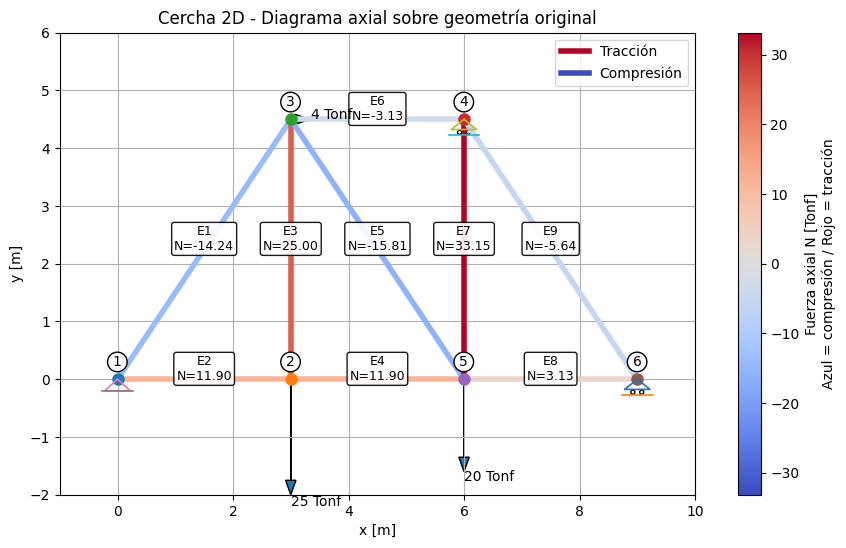

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.lines import Line2D

# ============================================================
# 1. Coordenadas de nodos
# ============================================================
coords = {
    1: np.array([0.0, 0.0]),
    2: np.array([3.0, 0.0]),
    3: np.array([3.0, 4.5]),
    4: np.array([6.0, 4.5]),
    5: np.array([6.0, 0.0]),
    6: np.array([9.0, 0.0]),
}

# ============================================================
# 2. Conectividad de elementos
# ============================================================
conect = {
    1: (1, 3),
    2: (1, 2),
    3: (2, 3),
    4: (2, 5),
    5: (3, 5),
    6: (3, 4),
    7: (4, 5),
    8: (5, 6),
    9: (4, 6),
}

# ============================================================
# 3. Objetos elemento
# ============================================================
elems_obj = {
    1: e1,
    2: e2,
    3: e3,
    4: e4,
    5: e5,
    6: e6,
    7: e7,
    8: e8,
    9: e9,
}

# ============================================================
# 4. Fuerzas axiales
# ============================================================
N_elem = {}
for e_id, elem in elems_obj.items():
    N_elem[e_id] = float(elem.obtenerFuerzaAxial())

# ============================================================
# 5. Funciones auxiliares
# ============================================================
def dibujar_apoyo_articulado(ax, x, y, size=0.22):
    tri = np.array([
        [x, y],
        [x - size, y - size*0.9],
        [x + size, y - size*0.9],
        [x, y]
    ])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=1.2)
    ax.plot([x - 1.2*size, x + 1.2*size], [y - size*0.95, y - size*0.95], linewidth=1.2)

def dibujar_apoyo_rodillo(ax, x, y, size=0.22):
    tri = np.array([
        [x, y],
        [x - size, y - size*0.8],
        [x + size, y - size*0.8],
        [x, y]
    ])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=1.2)

    circ1 = plt.Circle((x - size*0.35, y - size*1.02), size*0.16, fill=False)
    circ2 = plt.Circle((x + size*0.35, y - size*1.02), size*0.16, fill=False)
    ax.add_patch(circ1)
    ax.add_patch(circ2)

    ax.plot([x - 1.2*size, x + 1.2*size], [y - size*1.23, y - size*1.23], linewidth=1.2)

def flecha_carga(ax, x, y, fx=0.0, fy=0.0, scale=0.08, texto=None):
    ax.arrow(
        x, y,
        fx*scale, fy*scale,
        head_width=0.18, head_length=0.25,
        length_includes_head=True
    )
    if texto is not None:
        ax.text(x + fx*scale*1.1, y + fy*scale*1.1, texto, fontsize=10)

# ============================================================
# 6. Figura: diagrama axial
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))

# rango para colores
N_vals = np.array(list(N_elem.values()))
Nmax = np.max(np.abs(N_vals)) if len(N_vals) > 0 else 1.0

norm = colors.Normalize(vmin=-Nmax, vmax=Nmax)
cmap = cm.get_cmap("coolwarm")  # azul compresión, rojo tracción

# Dibujar elementos coloreados por fuerza axial
for e_id, (ni, nj) in conect.items():
    xi, yi = coords[ni]
    xj, yj = coords[nj]

    N = N_elem[e_id]
    col = cmap(norm(N))

    ax.plot([xi, xj], [yi, yj], linewidth=4, color=col)

    # punto medio
    xm, ym = (xi + xj)/2, (yi + yj)/2

    # texto con número de elemento y axial
    estado = "T" if N > 0 else "C" if N < 0 else "0"
    ax.text(
        xm, ym + 0.18,
        f"E{e_id}\nN={N:.2f}",
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.9)
    )

# Dibujar nodos
for nid, (x, y) in coords.items():
    ax.plot(x, y, 'o', markersize=8)
    ax.text(
        x - 0.08, y + 0.23, f"{nid}",
        fontsize=10,
        bbox=dict(boxstyle="circle,pad=0.2", facecolor="white")
    )

# Apoyos
dibujar_apoyo_articulado(ax, 0.0, 0.0, size=0.22)   # nodo 1
dibujar_apoyo_rodillo(ax, 6.0, 4.5, size=0.22)      # nodo 4
dibujar_apoyo_rodillo(ax, 9.0, 0.0, size=0.22)      # nodo 6

# Cargas
flecha_carga(ax, 3.0, 4.5, fx=4, fy=0, texto="4 Tonf")
flecha_carga(ax, 3.0, 0.0, fx=0, fy=-25, texto="25 Tonf")
flecha_carga(ax, 6.0, 0.0, fx=0, fy=-20, texto="20 Tonf")

# barra de color
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Fuerza axial N [Tonf]\nAzul = compresión / Rojo = tracción")

# leyenda simple
legend_elements = [
    Line2D([0], [0], color=cmap(norm(Nmax)), lw=4, label='Tracción'),
    Line2D([0], [0], color=cmap(norm(-Nmax)), lw=4, label='Compresión'),
]
ax.legend(handles=legend_elements, loc="upper right")

ax.set_title("Cercha 2D - Diagrama axial sobre geometría original")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.grid(True)
ax.set_xlim(-1, 10)
ax.set_ylim(-2, 6)

plt.show()